# Hands-on 5 — Real-world models: photon-count imaging and tomography

**Course:** NIFTy in a day · **Session:** 16:45 – 17:45

Real NIFTy applications (X-ray / γ-ray imaging, radio interferometry, 3-D dust maps, medical imaging) combine the
pieces you know into **generative models with several components and non-Gaussian likelihoods**.

**You will build**
1. A **photon-count imaging** model: diffuse emission (log-normal correlated field) → blurred by a PSF → multiplied by an exposure map with dead pixels → **Poisson** likelihood. Plus an honest look at why adding point sources makes it much harder.
2. A **tomography** model: a positive 2-D density observed only through **line-of-sight integrals** (`jft.SamplingCartesianGridLOS`).

In [1]:
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
import numpy as np

import nifty.re as jft

jax.config.update("jax_enable_x64", True)
plt.rcParams["figure.dpi"] = 90
key = random.PRNGKey(2026)

def im(ax, a, t, **kw):
    h = ax.imshow(np.asarray(a).T, origin="lower", cmap=kw.pop("cmap", "inferno"), **kw)
    ax.set_title(t); ax.set_xticks([]); ax.set_yticks([]); plt.colorbar(h, ax=ax, fraction=0.046)

## Part A — Photon-count imaging

### A.1 The generative model
$$ \lambda = E \cdot \big(\mathrm{PSF} * e^{\phi}\big), \qquad d \sim \mathrm{Poisson}(\lambda) $$

* **diffuse** $e^{\phi}$, $\phi$ a correlated field → smooth, positive, multi-scale.
* **PSF** blur via FFT; **exposure** $E$: how long each pixel was observed (here: a gradient, plus a dead strip).

**Poisson likelihood:** $-\ln P(d|\lambda) = \sum_x (\lambda_x - d_x\ln\lambda_x) + \text{const}$. Its Fisher metric is $\mathrm{diag}(1/\lambda)$: brighter pixels carry more information.

In [2]:
dims = (64, 64)
cfm = jft.CorrelatedFieldMaker("diffuse")
cfm.set_amplitude_total_offset(offset_mean=0.0, offset_std=(0.5, 0.1))
cfm.add_fluctuations(dims, distances=1 / dims[0], fluctuations=(0.8, 0.3), loglogavgslope=(-4.0, 0.5),
                     flexibility=(0.5, 0.3), asperity=None, prefix="", non_parametric_kind="power")
log_diffuse = cfm.finalize()

kx = jnp.fft.fftfreq(dims[0]) * dims[0]
psf_ft = jnp.exp(-0.5 * (jnp.sqrt(kx[:, None] ** 2 + kx[None, :] ** 2) / 12.0) ** 2)   # Gaussian PSF in Fourier space
exposure = jnp.broadcast_to(jnp.linspace(0.5, 2.0, dims[0])[:, None], dims)
exposure = exposure.at[24:36, :].set(0.0)                                                # dead detector strip (12 px)


class SkyModel(jft.Model):
    def __init__(self):
        self.log_diffuse = log_diffuse
        super().__init__(init=self.log_diffuse.init)

    def diffuse(self, xi):
        return jnp.exp(self.log_diffuse(xi))

    def sky(self, xi):
        return self.diffuse(xi)

    def __call__(self, xi):                         # expected counts λ
        blurred = jnp.fft.ifft2(psf_ft * jnp.fft.fft2(self.sky(xi))).real
        return exposure * jnp.clip(blurred, 1e-10)  # λ must stay > 0 for the Poisson likelihood


model = SkyModel()
print("latent parameters:", list(model.domain.keys()))

latent parameters: ['diffuseflexibility', 'diffusefluctuations', 'diffuseloglogavgslope', 'diffusespectrum', 'diffusexi', 'diffusezeromode']


### A.2 Prior predictive check — always look at prior samples first

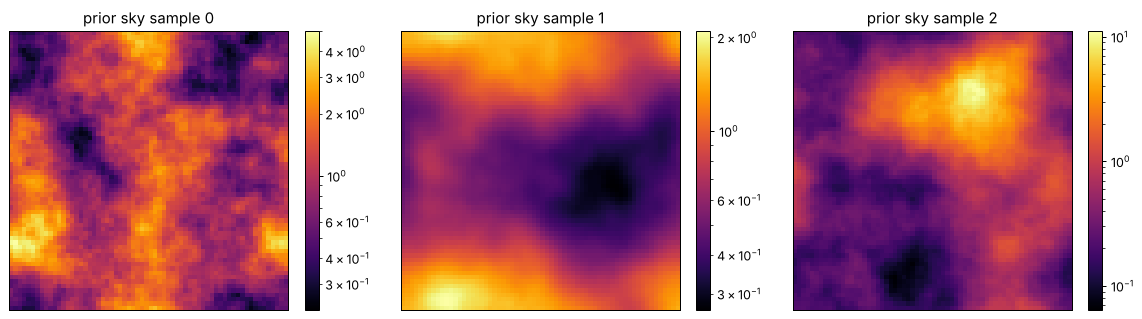

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(13, 3.6))
for i, ax in enumerate(axs):
    xi = model.init(random.PRNGKey(i))
    im(ax, model.sky(xi), f"prior sky sample {i}", norm=plt.matplotlib.colors.LogNorm())
plt.tight_layout(); plt.show()

### A.3 Synthetic data and the Poisson likelihood

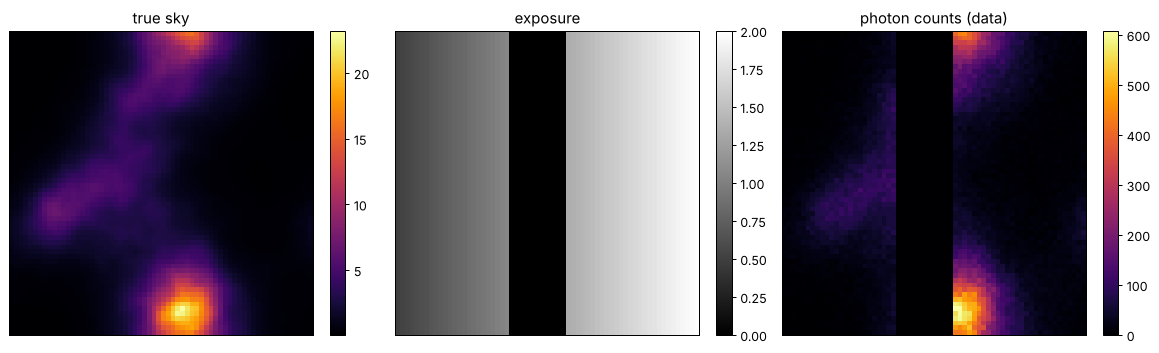

In [4]:
key, k_t, k_d = random.split(key, 3)
xi_true = jft.Vector(model.init(k_t))
lam_true = model(xi_true)
counts = random.poisson(k_d, lam_true * 20.0).astype(jnp.int64)   # ×20: a moderately bright observation


class Scaled(jft.Model):                                           # include the ×20 brightness in the model
    def __init__(self, m):
        self.m = m
        super().__init__(init=m.init)

    def __call__(self, xi):
        return 20.0 * self.m(xi)[observed]   # only pixels with exposure > 0 are data


# Pixels with zero exposure carry no data. Leaving them in would give λ = 0 and 0·log(0) = NaN in the Poisson
# energy — so the response must *select* the exposed pixels (exactly like the mask in Hands-on 2).
observed = exposure > 0
lh = jft.Poissonian(counts[observed]).amend(Scaled(model))

fig, axs = plt.subplots(1, 3, figsize=(13, 3.8))
im(axs[0], model.sky(xi_true), "true sky")
im(axs[1], exposure, "exposure", cmap="gray")
im(axs[2], counts, "photon counts (data)")
plt.tight_layout(); plt.show()

### A.4 Inference

<frozen genericpath>:39: RuntimeWarning: bool is used as a file descriptor
OPTIMIZE_KL: Starting 0001


OPTIMIZE_KL: Iteration 0001 E:-5.3946e+05
OPTIMIZE_KL: Linear sampling status (0, 0)
OPTIMIZE_KL: #(KL minimization steps) 15
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     9.8±     5.7, avg:   -0.057±    0.65, #dof:   3328'

OPTIMIZE_KL: Prior residual(s):
diffuseflexibility      :: 'reduced Chi²:     1.4±     1.3, avg:    -0.29±     1.2, #dof:      1'
diffusefluctuations     :: 'reduced Chi²: 1.5e+01±     6.4, avg:     +3.7±    0.85, #dof:      1'
diffuseloglogavgslope   :: 'reduced Chi²:   1e+01±     5.6, avg:     -3.1±    0.89, #dof:      1'
diffusespectrum         :: 'reduced Chi²:    0.99±   0.047, avg:   +0.034±   0.043, #dof:    910'
diffusexi               :: 'reduced Chi²:    0.94±   0.012, avg: -0.00067±  0.0064, #dof:   4096'
diffusezeromode         :: 'reduced Chi²:     4.1±     4.3, avg:     +1.3±     1.6, #dof:      1'




OPTIMIZE_KL: Starting 0002


OPTIMIZE_KL: Iteration 0002 E:-5.5189e+05
OPTIMIZE_KL: Linear sampling status (0, 0)
OPTIMIZE_KL: #(KL minimization steps) 11
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     1.2±   0.012, avg:   -0.019±     0.1, #dof:   3328'

OPTIMIZE_KL: Prior residual(s):
diffuseflexibility      :: 'reduced Chi²:     2.3±     2.0, avg:     -1.3±    0.72, #dof:      1'
diffusefluctuations     :: 'reduced Chi²: 1.6e+01±     5.4, avg:     +4.0±    0.67, #dof:      1'
diffuseloglogavgslope   :: 'reduced Chi²: 1.8e+01±     4.7, avg:     -4.2±    0.56, #dof:      1'
diffusespectrum         :: 'reduced Chi²:    0.97±   0.012, avg:   +0.039±   0.054, #dof:    910'
diffusexi               :: 'reduced Chi²:     1.0±   0.017, avg: -0.00058±  0.0044, #dof:   4096'
diffusezeromode         :: 'reduced Chi²:     1.8±     1.8, avg:     +1.1±    0.81, #dof:      1'




OPTIMIZE_KL: Starting 0003


...

OPTIMIZE_KL: Iteration 0004 E:-5.5188e+05
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 3
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     1.3±     0.1, avg:  +0.0042±   0.098, #dof:   3328'

OPTIMIZE_KL: Prior residual(s):
diffuseflexibility      :: 'reduced Chi²:     3.3±     3.5, avg:     -1.4±     1.2, #dof:      1'
diffusefluctuations     :: 'reduced Chi²: 1.7e+01±     6.8, avg:     +4.0±    0.86, #dof:      1'
diffuseloglogavgslope   :: 'reduced Chi²: 1.7e+01±     2.6, avg:     -4.2±    0.31, #dof:      1'
diffusespectrum         :: 'reduced Chi²:     1.0±   0.072, avg:    +0.04±   0.033, #dof:    910'
diffusexi               :: 'reduced Chi²:    0.99±   0.035, avg:  -0.0006±  0.0074, #dof:   4096'
diffusezeromode         :: 'reduced Chi²:     1.2±    0.66, avg:     +1.1±    0.31, #dof:      1'




OPTIMIZE_KL: Starting 0005


OPTIMIZE_KL: Iteration 0005 E:-5.5200e+05
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 1
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     1.2±   0.065, avg:  -0.0097±   0.062, #dof:   3328'

OPTIMIZE_KL: Prior residual(s):
diffuseflexibility      :: 'reduced Chi²:     2.4±     1.9, avg:     -1.4±    0.68, #dof:      1'
diffusefluctuations     :: 'reduced Chi²: 1.6e+01±     4.4, avg:     +3.9±    0.55, #dof:      1'
diffuseloglogavgslope   :: 'reduced Chi²: 1.7e+01±     3.8, avg:     -4.2±    0.46, #dof:      1'
diffusespectrum         :: 'reduced Chi²:     1.1±   0.038, avg:    +0.04±   0.021, #dof:    910'
diffusexi               :: 'reduced Chi²:    0.99±   0.029, avg:  -0.0006±   0.012, #dof:   4096'
diffusezeromode         :: 'reduced Chi²:     1.4±     1.1, avg:     +1.1±     0.5, #dof:      1'




OPTIMIZE_KL: Starting 0006


OPTIMIZE_KL: Iteration 0006 E:-5.5198e+05
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 1
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     1.2±   0.051, avg:   +0.014±   0.046, #dof:   3328'

OPTIMIZE_KL: Prior residual(s):
diffuseflexibility      :: 'reduced Chi²:     2.5±     2.0, avg:     -1.4±     0.7, #dof:      1'
diffusefluctuations     :: 'reduced Chi²: 1.6e+01±     3.6, avg:     +3.9±    0.45, #dof:      1'
diffuseloglogavgslope   :: 'reduced Chi²: 1.8e+01±     5.0, avg:     -4.1±     0.6, #dof:      1'
diffusespectrum         :: 'reduced Chi²:     1.1±   0.032, avg:    +0.04±   0.031, #dof:    910'
diffusexi               :: 'reduced Chi²:    0.99±   0.023, avg:  -0.0006±  0.0084, #dof:   4096'
diffusezeromode         :: 'reduced Chi²:     1.6±     1.6, avg:     +1.1±    0.68, #dof:      1'




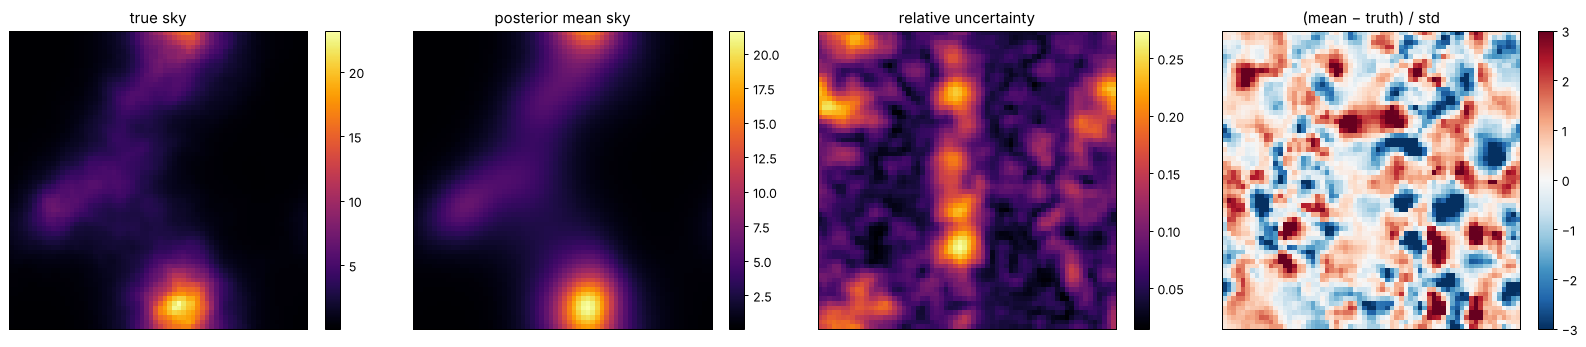

pixels within 1σ: 0.56 (ideal 0.68)   within 2σ: 0.84 (ideal 0.95)


In [5]:
delta = 1e-4
key, k_i, k_o = random.split(key, 3)
samples, state = jft.optimize_kl(
    lh, jft.Vector(lh.init(k_i)) * 0.1, n_total_iterations=6, key=k_o,
    n_samples=lambda i: 2 if i < 3 else 4,
    # MGVI throughout keeps this cell at a few minutes on a laptop. For the final science run you'd switch the
    # last iterations to "nonlinear_resample" (geoVI) — more accurate, ~5x slower here.
    sample_mode="linear_resample",
    draw_linear_kwargs=dict(cg_name=None, cg_kwargs=dict(absdelta=delta * jft.size(lh.domain) / 10, maxiter=100)),
    nonlinearly_update_kwargs=dict(minimize_kwargs=dict(name=None, xtol=delta, cg_kwargs=dict(name=None), maxiter=5)),
    kl_kwargs=dict(minimize_kwargs=dict(name=None, xtol=delta, cg_kwargs=dict(name=None), maxiter=20)),
)

dm, ds = jft.mean_and_std(tuple(model.sky(s) for s in samples))
fig, axs = plt.subplots(1, 4, figsize=(18, 3.8))
im(axs[0], model.sky(xi_true), "true sky"); im(axs[1], dm, "posterior mean sky")
im(axs[2], ds / dm, "relative uncertainty")
z = (dm - model.sky(xi_true)) / ds
im(axs[3], z, "(mean − truth) / std", cmap="RdBu_r", vmin=-3, vmax=3)
plt.tight_layout(); plt.show()
print(f"pixels within 1σ: {float((jnp.abs(z) < 1).mean()):.2f} (ideal 0.68)   within 2σ: {float((jnp.abs(z) < 2).mean()):.2f} (ideal 0.95)")

Things to notice:
* The **dead strip** is filled in by the correlated-field prior; the relative uncertainty is higher there than in its exposed neighbours.
* Relative uncertainty grows towards the left, where the exposure is lower: fewer photons, less information.
* The last panel is the calibration check. With only 8 posterior samples the std itself is a noisy estimate,
  so expect fewer pixels inside 1σ than the ideal 68%. More samples (and geoVI in the final iterations) improve the
  calibration — try `n_samples=lambda i: 2 if i < 3 else 16` and compare the printed fractions.

### A.5 Expert note — why point sources are hard
Real X-ray/γ-ray skies also contain **point sources**. The standard NIFTy approach adds a second component
$p_x \sim \text{InvGamma}(\alpha, q)$ per pixel: mostly tiny, occasionally huge, and the different prior *shapes*
(smooth vs. sparse) let the inference separate them. In practice this is one of the hardest NIFTy problems:
the inverse-gamma map has a gradient of ~0.003 at $\xi=0$ but needs $\xi\approx 3$–4 to make a bright source,
so early on the smooth diffuse field "explains" every bright spot first and the point latents barely move.
When we tried it here with a naive setup (12 MGVI iterations), the point component recovered none of the bright
sources. Working pipelines use more iterations, a stiffer diffuse prior early on, staged inference
(diffuse first, then points) and careful initialisation. Exercise E5.2 lets you explore this.

## Part B — Tomography with line-of-sight integrals

We observe a positive 2-D density $\rho = e^{\phi}$ only through integrals along straight lines:
$d_i = \int_{\text{LOS}_i} \rho\, dl + n_i$. `jft.SamplingCartesianGridLOS(start, end, shape=, distances=)`
builds that integration operator (it samples points along each line and interpolates the grid).

assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


OPTIMIZE_KL: Starting 0001


N: Iteration Limit Reached


OPTIMIZE_KL: Iteration 0001 E:+3.2195e+03
OPTIMIZE_KL: Linear sampling status (0, 0)
OPTIMIZE_KL: #(KL minimization steps) 20
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     2.6±    0.27, avg:     +0.1±    0.42, #dof:    300'

OPTIMIZE_KL: Prior residual(s):
rhoflexibility          :: 'reduced Chi²:     2.2±     1.1, avg:     +1.4±    0.37, #dof:      1'
rhofluctuations         :: 'reduced Chi²: 1.3e+01±     9.4, avg:     -3.3±     1.4, #dof:      1'
rhologlogavgslope       :: 'reduced Chi²:     6.8±     5.3, avg:     +2.3±     1.1, #dof:      1'
rhospectrum             :: 'reduced Chi²:     1.1±   0.047, avg:    -0.15±   0.022, #dof:    910'
rhoxi                   :: 'reduced Chi²:     1.1±   0.077, avg:  +0.0055±   0.017, #dof:   4096'
rhozeromode             :: 'reduced Chi²: 1.4e+01±   1e+01, avg:     +3.4±     1.5, #dof:      1'




OPTIMIZE_KL: Starting 0002


...

OPTIMIZE_KL: Iteration 0004 E:+2.7327e+03
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 16
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     1.2±     0.2, avg:   +0.037±    0.22, #dof:    300'

OPTIMIZE_KL: Prior residual(s):
rhoflexibility          :: 'reduced Chi²:     7.4±     3.4, avg:     +2.7±    0.64, #dof:      1'
rhofluctuations         :: 'reduced Chi²:     6.9±     0.5, avg:     -2.6±   0.095, #dof:      1'
rhologlogavgslope       :: 'reduced Chi²:     4.6±     1.9, avg:     +2.1±    0.46, #dof:      1'
rhospectrum             :: 'reduced Chi²:    0.99±   0.025, avg:   -0.036±   0.032, #dof:    910'
rhoxi                   :: 'reduced Chi²:     1.0±   0.011, avg:  +0.0022±   0.022, #dof:   4096'
rhozeromode             :: 'reduced Chi²:     4.0±     2.0, avg:     +1.9±    0.52, #dof:      1'




OPTIMIZE_KL: Starting 0005


OPTIMIZE_KL: Iteration 0005 E:+2.8718e+03
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 17
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     1.6±    0.51, avg:   +0.059±    0.23, #dof:    300'

OPTIMIZE_KL: Prior residual(s):
rhoflexibility          :: 'reduced Chi²:     3.2±     2.7, avg:     +1.6±    0.82, #dof:      1'
rhofluctuations         :: 'reduced Chi²:     9.7±     1.6, avg:     -3.1±    0.25, #dof:      1'
rhologlogavgslope       :: 'reduced Chi²:     2.5±     2.5, avg:     +1.3±    0.95, #dof:      1'
rhospectrum             :: 'reduced Chi²:     1.0±   0.052, avg:   -0.053±   0.018, #dof:    910'
rhoxi                   :: 'reduced Chi²:     1.1±   0.014, avg:  +0.0021±   0.011, #dof:   4096'
rhozeromode             :: 'reduced Chi²:     4.8±     3.1, avg:     +2.1±    0.73, #dof:      1'




OPTIMIZE_KL: Starting 0006


OPTIMIZE_KL: Iteration 0006 E:+2.7508e+03
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 14
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     1.3±    0.15, avg:   +0.044±    0.22, #dof:    300'

OPTIMIZE_KL: Prior residual(s):
rhoflexibility          :: 'reduced Chi²:     2.4±     2.3, avg:     +1.3±    0.78, #dof:      1'
rhofluctuations         :: 'reduced Chi²:     9.0±     2.4, avg:     -3.0±    0.41, #dof:      1'
rhologlogavgslope       :: 'reduced Chi²:     2.5±     1.0, avg:     +1.5±    0.34, #dof:      1'
rhospectrum             :: 'reduced Chi²:     1.0±   0.022, avg:   -0.026±   0.042, #dof:    910'
rhoxi                   :: 'reduced Chi²:     1.0±   0.026, avg:  +0.0021±   0.013, #dof:   4096'
rhozeromode             :: 'reduced Chi²:     3.6±     2.9, avg:     +1.7±    0.85, #dof:      1'




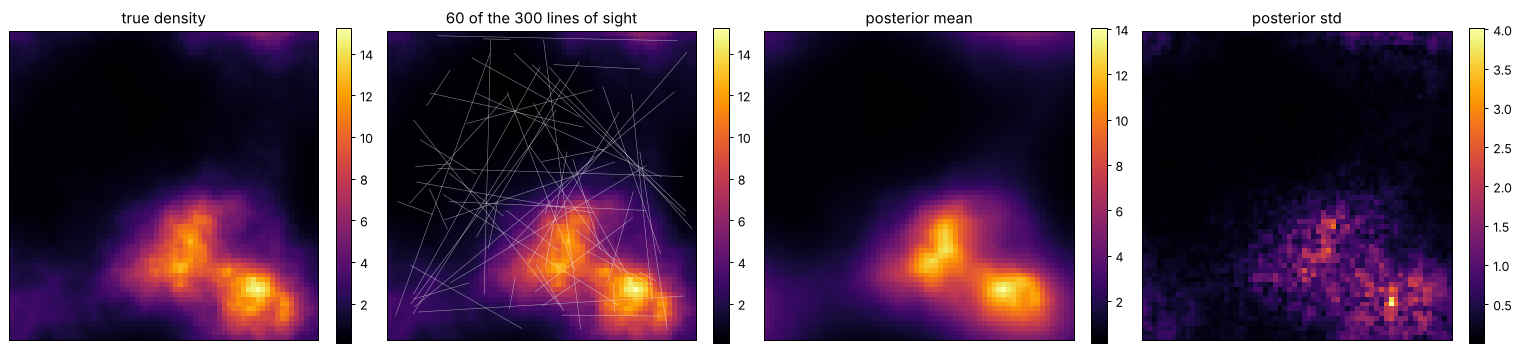

In [6]:
dims_t = (64, 64)
dist_t = tuple(1.0 / d for d in dims_t)
cfm_t = jft.CorrelatedFieldMaker("rho")
cfm_t.set_amplitude_total_offset(offset_mean=0.0, offset_std=(0.3, 0.1))
cfm_t.add_fluctuations(dims_t, distances=dist_t, fluctuations=(1.0, 0.3), loglogavgslope=(-4.0, 0.5),
                       flexibility=(0.5, 0.2), asperity=None, prefix="", non_parametric_kind="power")
log_rho = cfm_t.finalize()

n_los = 300
key, k_s, k_e = random.split(key, 3)
starts = random.uniform(k_s, (n_los, 2), minval=0.02, maxval=0.98)
ends = random.uniform(k_e, (n_los, 2), minval=0.02, maxval=0.98)
los = jft.SamplingCartesianGridLOS(starts, ends, distances=dist_t, shape=dims_t, n_sampling_points=200)


class Tomo(jft.Model):
    def __init__(self):
        self.log_rho = log_rho
        super().__init__(init=log_rho.init)

    def rho(self, xi):
        return jnp.exp(self.log_rho(xi))

    def __call__(self, xi):
        return los(self.rho(xi))


tomo = Tomo()
key, k_t, k_n = random.split(key, 3)
xi_t = jft.Vector(tomo.init(k_t))
clean = tomo(xi_t)
sig = 0.05 * clean                                    # 5% relative noise
d_t = clean + sig * random.normal(k_n, clean.shape)
lh_t = jft.Gaussian(d_t, noise_cov_inv=lambda r: r / sig**2).amend(tomo)

key, k_i, k_o = random.split(key, 3)
smp_t, _ = jft.optimize_kl(
    lh_t, jft.Vector(lh_t.init(k_i)) * 0.1, n_total_iterations=6, n_samples=lambda i: 2 if i < 2 else 4, key=k_o,
    sample_mode="linear_resample",
    draw_linear_kwargs=dict(cg_name=None, cg_kwargs=dict(absdelta=delta * jft.size(lh_t.domain) / 10, maxiter=100)),
    nonlinearly_update_kwargs=dict(minimize_kwargs=dict(name=None, xtol=delta, cg_kwargs=dict(name=None), maxiter=5)),
    kl_kwargs=dict(minimize_kwargs=dict(name=None, xtol=delta, cg_kwargs=dict(name=None), maxiter=20)),
)
rm, rs = jft.mean_and_std(tuple(tomo.rho(s) for s in smp_t))

fig, axs = plt.subplots(1, 4, figsize=(17, 3.9))
im(axs[0], tomo.rho(xi_t), "true density")
for s_, e_ in zip(np.asarray(starts[:60]), np.asarray(ends[:60])):
    axs[1].plot([s_[0] * 64, e_[0] * 64], [s_[1] * 64, e_[1] * 64], "w-", lw=0.4, alpha=0.6)
im(axs[1], tomo.rho(xi_t), "60 of the 300 lines of sight")
im(axs[2], rm, "posterior mean")
im(axs[3], rs, "posterior std")
plt.tight_layout(); plt.show()

Each datum is a *single number* per line, yet the correlated-field prior makes the 4096-pixel image recoverable.
The uncertainty is lowest where many lines cross. The same model scales to 3-D (`demos/re/1_tomography.py`) —
that is how the 3-D Galactic dust maps were made with NIFTy.

## ✏️ Exercises
**E5.1** Reduce the brightness factor from 20 to 2 (fewer photons). How do the relative-uncertainty map and the small-scale structure change?

**E5.2 (advanced)** Add point sources to the *truth* (a handful of pixels set to 50). First fit the diffuse-only model and inspect `jft.minisanity(samples, lh.normalized_residual)` — where is the misfit? Then add `jft.InvGammaPrior(a=0.8, scale=1e-3, name="points", shape=dims)` to the model and try to make the separation work (stiffer diffuse prior, more iterations, two-stage fitting).

**E5.3** Tomography: use only 50 lines of sight, all starting from the same point (an "observer", like in dust mapping, `start=(0.5, 0.5)`). How does the uncertainty map look now?

**E5.4** Add an unknown **calibration factor** to the tomography data (`jft.LogNormalPrior(1.0, 0.2, name="calib")` multiplying the LOS integrals). Is it degenerate with anything in the correlated field? (Hint: `offset_mean`.)

In [7]:
# Your work here

---
## Solutions

assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


OPTIMIZE_KL: Starting 0001


N: Iteration Limit Reached


OPTIMIZE_KL: Iteration 0001 E:+3.5767e+03
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 20
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²: 4.1e+01± 2.9e+01, avg:     +2.2±     2.3, #dof:     50'

OPTIMIZE_KL: Prior residual(s):
rhoflexibility          :: 'reduced Chi²:     5.6±     6.7, avg:     +1.6±     1.7, #dof:      1'
rhofluctuations         :: 'reduced Chi²:     3.4±     1.9, avg:    -0.29±     1.8, #dof:      1'
rhologlogavgslope       :: 'reduced Chi²:     2.5±     2.5, avg:     -1.2±     1.0, #dof:      1'
rhospectrum             :: 'reduced Chi²:     1.0±   0.031, avg:    +0.02±   0.017, #dof:    910'
rhoxi                   :: 'reduced Chi²:     1.0±    0.02, avg:  +0.0044±  0.0054, #dof:   4096'
rhozeromode             :: 'reduced Chi²:     6.8±     5.8, avg:     -2.3±     1.2, #dof:      1'




OPTIMIZE_KL: Starting 0002


...

OPTIMIZE_KL: Iteration 0003 E:+2.5766e+03
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 20
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     1.9±    0.52, avg:   +0.041±    0.45, #dof:     50'

OPTIMIZE_KL: Prior residual(s):
rhoflexibility          :: 'reduced Chi²:     5.1±     4.8, avg:     +1.9±     1.2, #dof:      1'
rhofluctuations         :: 'reduced Chi²:     1.4±     1.3, avg:    -0.95±    0.69, #dof:      1'
rhologlogavgslope       :: 'reduced Chi²:     2.5±     2.7, avg:    -0.88±     1.3, #dof:      1'
rhospectrum             :: 'reduced Chi²:     1.0±   0.016, avg:  -0.0038±   0.028, #dof:    910'
rhoxi                   :: 'reduced Chi²:     1.0±   0.026, avg:  +0.0024±   0.015, #dof:   4096'
rhozeromode             :: 'reduced Chi²:     1.1±     1.2, avg:     +0.8±    0.68, #dof:      1'




OPTIMIZE_KL: Starting 0004


OPTIMIZE_KL: Iteration 0004 E:+2.5746e+03
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 9
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     1.8±    0.48, avg:   +0.066±    0.65, #dof:     50'

OPTIMIZE_KL: Prior residual(s):
rhoflexibility          :: 'reduced Chi²:     3.7±     1.8, avg:     +1.8±    0.49, #dof:      1'
rhofluctuations         :: 'reduced Chi²:     1.2±     0.8, avg:     -1.0±    0.39, #dof:      1'
rhologlogavgslope       :: 'reduced Chi²:     3.3±     3.6, avg:     -1.4±     1.2, #dof:      1'
rhospectrum             :: 'reduced Chi²:    0.95±   0.034, avg:  +0.0065±   0.032, #dof:    910'
rhoxi                   :: 'reduced Chi²:     1.0±   0.014, avg:   +0.002±   0.016, #dof:   4096'
rhozeromode             :: 'reduced Chi²:     1.8±     2.4, avg:    -0.18±     1.3, #dof:      1'




OPTIMIZE_KL: Starting 0005


OPTIMIZE_KL: Iteration 0005 E:+2.5456e+03
OPTIMIZE_KL: Linear sampling status (0, 0, 0, 0)
OPTIMIZE_KL: #(KL minimization steps) 8
OPTIMIZE_KL: Likelihood residual(s):
'reduced Chi²:     1.5±    0.34, avg:   +0.031±    0.44, #dof:     50'

OPTIMIZE_KL: Prior residual(s):
rhoflexibility          :: 'reduced Chi²:     5.5±     6.0, avg:     +1.7±     1.6, #dof:      1'
rhofluctuations         :: 'reduced Chi²:    0.88±    0.35, avg:    -0.92±    0.19, #dof:      1'
rhologlogavgslope       :: 'reduced Chi²:     2.6±     2.4, avg:     -1.4±    0.86, #dof:      1'
rhospectrum             :: 'reduced Chi²:     1.0±   0.027, avg:  +0.0074±   0.028, #dof:    910'
rhoxi                   :: 'reduced Chi²:     1.0±   0.011, avg:  +0.0013±   0.012, #dof:   4096'
rhozeromode             :: 'reduced Chi²:     2.2±     2.6, avg:     -0.8±     1.2, #dof:      1'




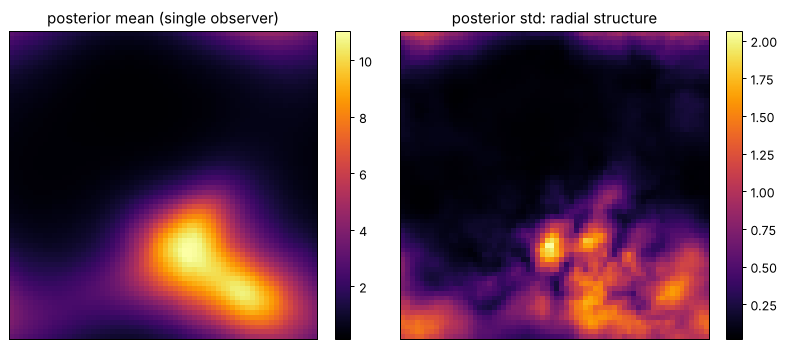

In [8]:
# E5.3 — single observer
starts_o = jnp.broadcast_to(jnp.array([0.5, 0.5]), (50, 2))
ends_o = random.uniform(random.PRNGKey(99), (50, 2), minval=0.02, maxval=0.98)
los_o = jft.SamplingCartesianGridLOS(starts_o, ends_o, distances=dist_t, shape=dims_t, n_sampling_points=200)


class TomoObs(Tomo):
    def __call__(self, xi):
        return los_o(self.rho(xi))


tomo_o = TomoObs()
clean_o = tomo_o(xi_t)
sig_o = 0.05 * clean_o
d_o = clean_o + sig_o * random.normal(random.PRNGKey(98), clean_o.shape)
lh_o = jft.Gaussian(d_o, noise_cov_inv=lambda r: r / sig_o**2).amend(tomo_o)
smp_o, _ = jft.optimize_kl(
    lh_o, jft.Vector(lh_o.init(random.PRNGKey(97))) * 0.1, n_total_iterations=5, n_samples=4, key=random.PRNGKey(96),
    sample_mode="linear_resample",
    draw_linear_kwargs=dict(cg_name=None, cg_kwargs=dict(maxiter=100)),
    nonlinearly_update_kwargs=dict(minimize_kwargs=dict(name=None, xtol=delta, cg_kwargs=dict(name=None), maxiter=5)),
    kl_kwargs=dict(minimize_kwargs=dict(name=None, xtol=delta, cg_kwargs=dict(name=None), maxiter=20)),
)
mo, so = jft.mean_and_std(tuple(tomo_o.rho(s) for s in smp_o))
fig, axs = plt.subplots(1, 2, figsize=(9, 3.9))
im(axs[0], mo, "posterior mean (single observer)"); im(axs[1], so, "posterior std: radial structure")
plt.tight_layout(); plt.show()